# A/B Test Analysis: Marketing Campaign Effectiveness

**Dataset:** [Marketing A/B Testing (Kaggle)](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing/data) — 588,101 users
**Question:** Does showing an ad increase conversion rate compared to a PSA (control)?

This notebook covers: data cleaning, EDA, hypothesis testing, power analysis, segment analysis, a predictive model with SHAP interpretability, and a Bayesian A/B test.

See `business_writeup.md` in this repo for the plain-English summary of findings.


## Step 1: Load & Clean

In [1]:
import pandas as pd

# ---- Load ----
df = pd.read_csv("marketing_AB.csv")   # replace with your actual filename once uploaded

# Kaggle's version usually ships with an extra unnamed index column - drop it if present
unnamed_cols = [c for c in df.columns if "Unnamed" in c]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

# Standardize column names (lowercase, underscores) so code is easier to write later
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)

# ---- Basic sanity checks ----
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# ---- Check group balance (this matters a LOT for this dataset) ----
print("\nTest group distribution:")
print(df["test_group"].value_counts())
print(df["test_group"].value_counts(normalize=True).round(4) * 100, "%")

# ---- Check target variable ----
print("\nConverted distribution:")
print(df["converted"].value_counts())
print("Overall conversion rate:", round(df["converted"].mean() * 100, 3), "%")

# ---- Conversion rate by group (the headline number) ----
conv_by_group = df.groupby("test_group")["converted"].mean().sort_values(ascending=False)
print("\nConversion rate by group:\n", (conv_by_group * 100).round(3))

# ---- Quick look at total_ads distribution ----
print("\nTotal ads seen - summary stats:\n", df["total_ads"].describe())

# ---- Save cleaned version ----
df.to_csv("marketing_AB_cleaned.csv", index=False)
print("\nSaved cleaned file as marketing_AB_cleaned.csv")


Shape: (588101, 6)

Column dtypes:
 user_id          int64
test_group         str
converted         bool
total_ads        int64
most_ads_day       str
most_ads_hour    int64
dtype: object

Missing values per column:
 user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

Duplicate rows: 0

Test group distribution:
test_group
ad     564577
psa     23524
Name: count, dtype: int64
test_group
ad     96.0
psa     4.0
Name: proportion, dtype: float64 %

Converted distribution:
converted
False    573258
True      14843
Name: count, dtype: int64
Overall conversion rate: 2.524 %

Conversion rate by group:
 test_group
ad     2.555
psa    1.785
Name: converted, dtype: float64

Total ads seen - summary stats:
 count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total_ads, dtype: float64

Sa

## Step 2: Exploratory Data Analysis

=== total_ads outlier check ===
count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
50%          13.000000
90%          57.000000
95%          88.000000
99%         202.000000
99.9%       499.900000
max        2065.000000
Name: total_ads, dtype: float64

Top 10 highest total_ads values:
       user_id test_group  converted  total_ads
26742  1184464         ad      False       2065
47005  1637962         ad       True       1778
7187   1209450         ad       True       1680
506    1086307         ad      False       1632
15334  1512157         ad       True       1491
16525  1416565         ad      False       1414
9605   1596993         ad      False       1398
80496  1351117         ad       True       1391
27800  1200489         ad       True       1354
107    1389878         ad       True       1328

99th percentile of total_ads: 202.0
Number of users above 99th percentile: 5810

=== Conversion rate by group ===
test_group
ad     2.555
psa  

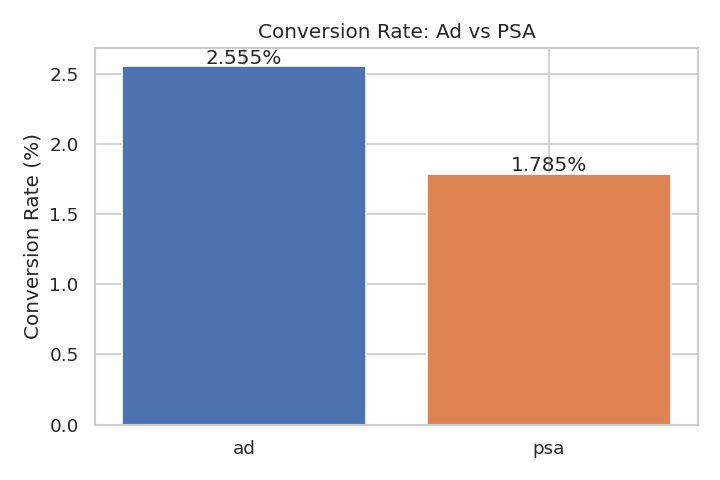

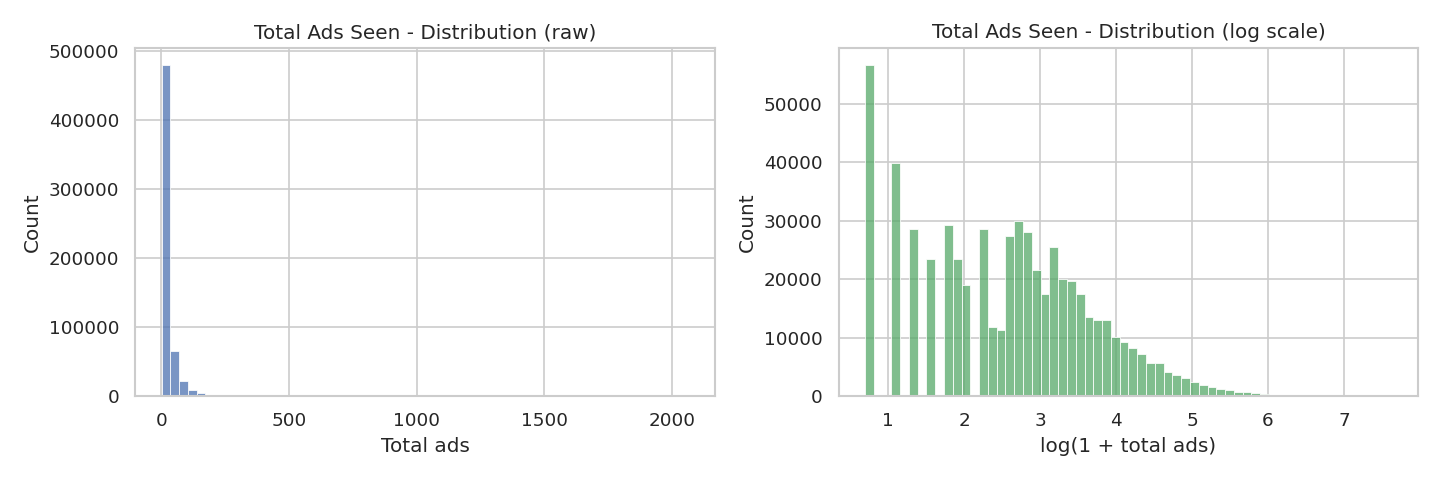

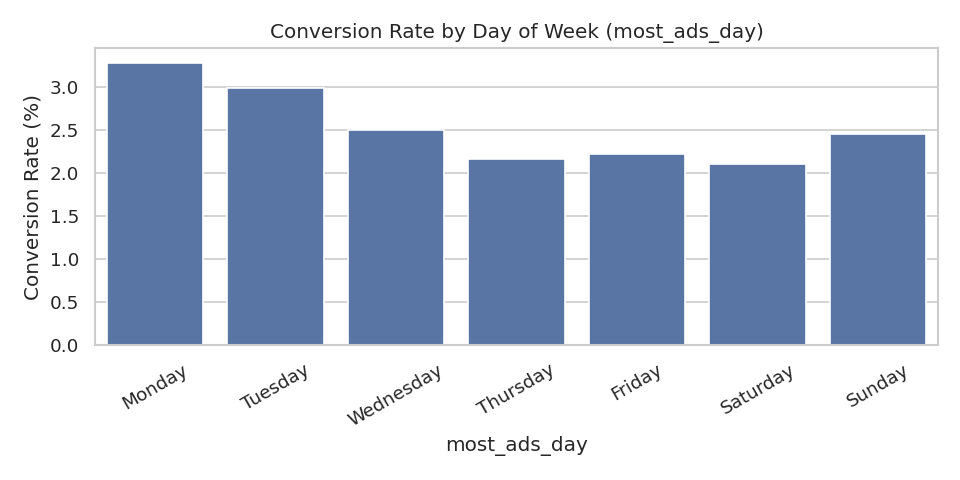

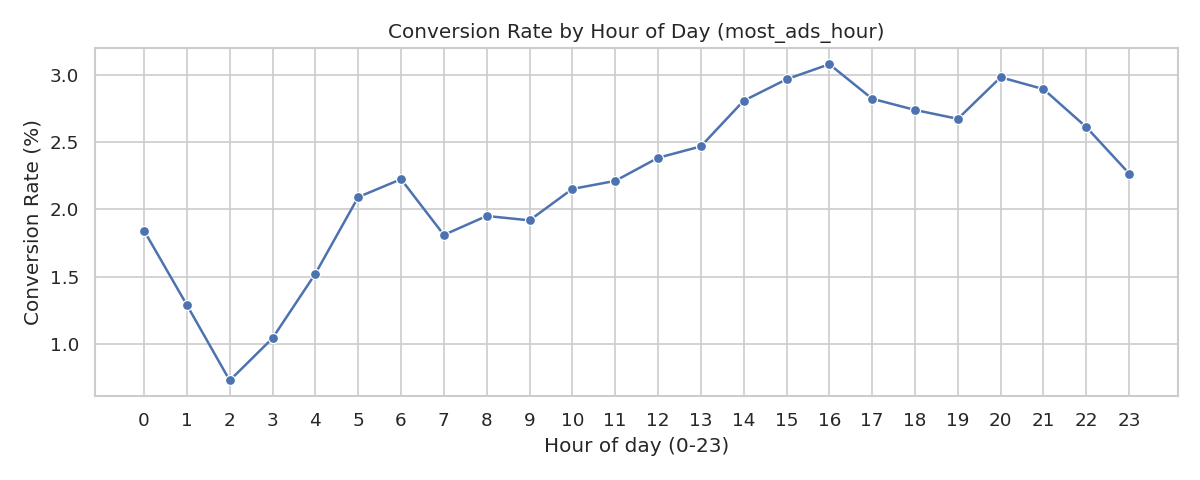

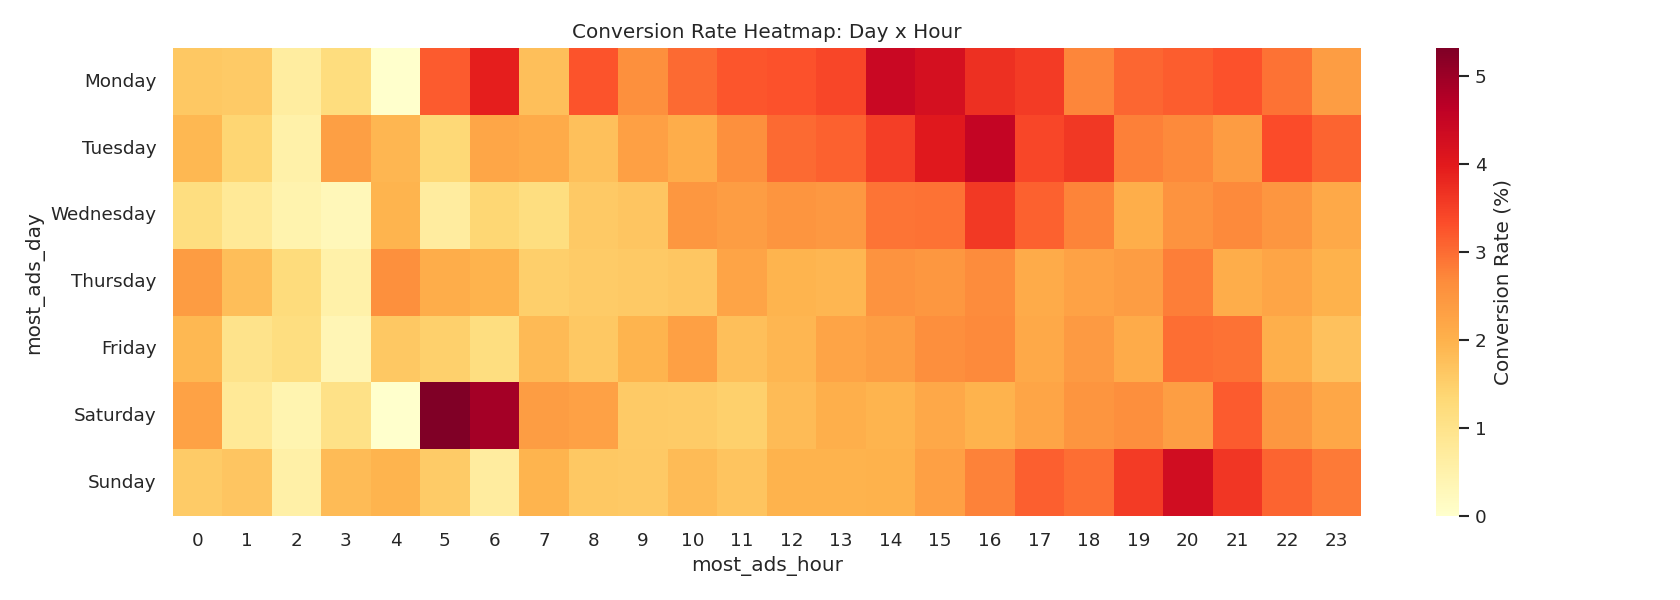

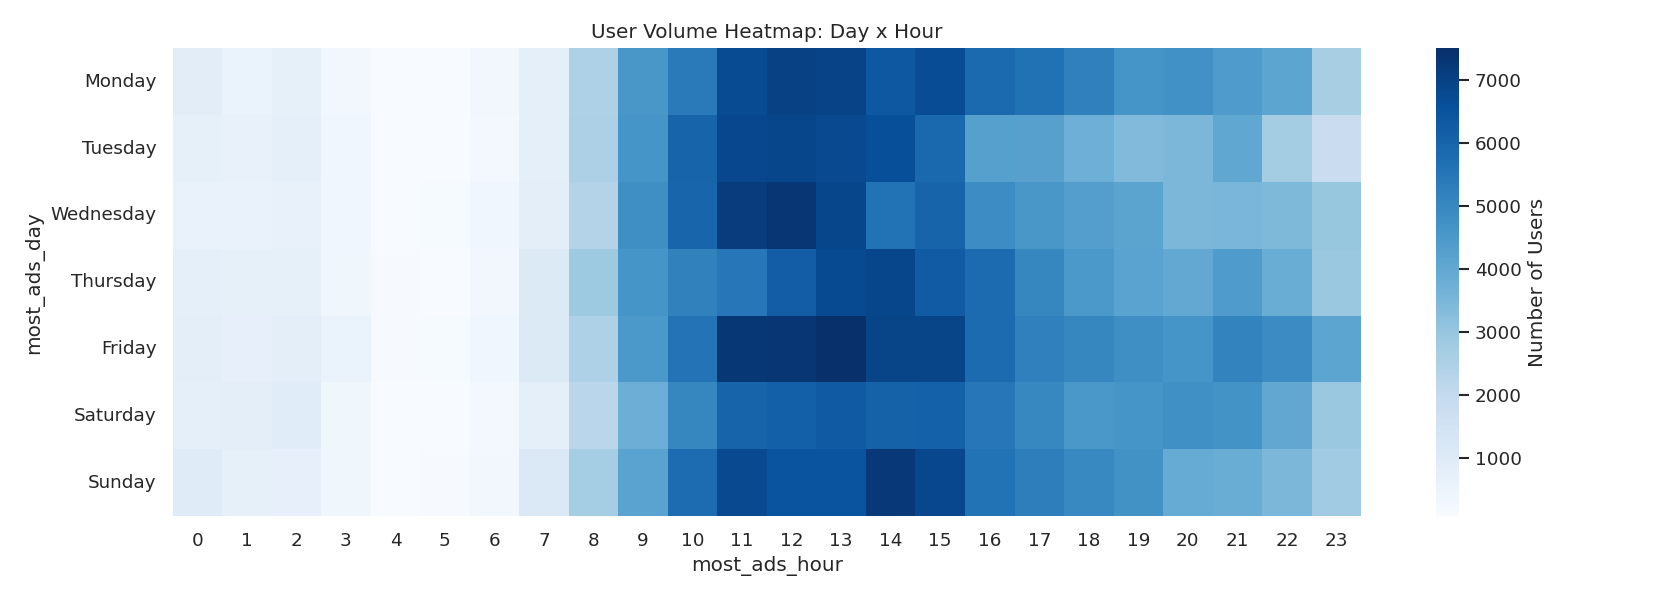

In [2]:
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
df = pd.read_csv("marketing_AB_cleaned.csv")

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# 1. Conversion rate by test group
conv_by_group = df.groupby("test_group")["converted"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(conv_by_group.index, conv_by_group.values, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rate: Ad vs PSA")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.3f}%", ha="center")
plt.tight_layout()
plt.savefig("plot1_conversion_by_group.png", dpi=120)
plt.close()

# 2. total_ads distribution + outlier check
print("=== total_ads outlier check ===")
print(df["total_ads"].describe(percentiles=[.5, .9, .95, .99, .999]))
print("\nTop 10 highest total_ads values:")
print(df.sort_values("total_ads", ascending=False)[["user_id", "test_group", "converted", "total_ads"]].head(10))

p99 = df["total_ads"].quantile(0.99)
print(f"\n99th percentile of total_ads: {p99}")
print(f"Number of users above 99th percentile: {(df['total_ads'] > p99).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["total_ads"], bins=60, ax=axes[0])
axes[0].set_title("Total Ads Seen - Distribution (raw)")
axes[0].set_xlabel("Total ads")

sns.histplot(np.log1p(df["total_ads"]), bins=60, ax=axes[1], color="#55A868")
axes[1].set_title("Total Ads Seen - Distribution (log scale)")
axes[1].set_xlabel("log(1 + total ads)")
plt.tight_layout()
plt.savefig("plot2_total_ads_distribution.png", dpi=120)
plt.close()

# 3. Conversion rate by day of week
conv_by_day = df.groupby("most_ads_day")["converted"].mean().reindex(day_order) * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=conv_by_day.index, y=conv_by_day.values, ax=ax, color="#4C72B0")
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rate by Day of Week (most_ads_day)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("plot3_conversion_by_day.png", dpi=120)
plt.close()

# 4. Conversion rate by hour of day
conv_by_hour = df.groupby("most_ads_hour")["converted"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(x=conv_by_hour.index, y=conv_by_hour.values, marker="o", ax=ax)
ax.set_xlabel("Hour of day (0-23)")
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rate by Hour of Day (most_ads_hour)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig("plot4_conversion_by_hour.png", dpi=120)
plt.close()

# 5. Heatmap: Day x Hour conversion rate
pivot = df.pivot_table(index="most_ads_day", columns="most_ads_hour", values="converted", aggfunc="mean")
pivot = pivot.reindex(day_order)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot * 100, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Conversion Rate (%)"})
ax.set_title("Conversion Rate Heatmap: Day x Hour")
plt.tight_layout()
plt.savefig("plot5_heatmap_day_hour.png", dpi=120)
plt.close()

# 6. User volume by day/hour (context for the heatmap above)
pivot_counts = df.pivot_table(index="most_ads_day", columns="most_ads_hour", values="user_id", aggfunc="count")
pivot_counts = pivot_counts.reindex(day_order)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_counts, cmap="Blues", ax=ax, cbar_kws={"label": "Number of Users"})
ax.set_title("User Volume Heatmap: Day x Hour")
plt.tight_layout()
plt.savefig("plot6_heatmap_volume.png", dpi=120)
plt.close()

# Print summary numbers
print("\n=== Conversion rate by group ===")
print(conv_by_group.round(3))

print("\n=== Conversion rate by day ===")
print(conv_by_day.round(3))

print("\n=== Conversion rate by hour ===")
print(conv_by_hour.round(3))

print("\n=== Best day ===", conv_by_day.idxmax(), f"({conv_by_day.max():.3f}%)")
print("=== Worst day ===", conv_by_day.idxmin(), f"({conv_by_day.min():.3f}%)")
print("=== Best hour ===", conv_by_hour.idxmax(), f"({conv_by_hour.max():.3f}%)")
print("=== Worst hour ===", conv_by_hour.idxmin(), f"({conv_by_hour.min():.3f}%)")

print("\nAll 6 plots saved.")


## Step 3: Core Hypothesis Test (Two-Proportion Z-Test + Chi-Square)

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

df = pd.read_csv("marketing_AB_cleaned.csv")

# =========================================================
# 1. Build contingency table
# =========================================================
contingency = pd.crosstab(df["test_group"], df["converted"])
print("Contingency table (rows=group, cols=converted):")
print(contingency)

# =========================================================
# 2. Chi-square test of independence
# =========================================================
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"\n--- Chi-square test ---")
print(f"Chi2 statistic: {chi2:.4f}")
print(f"p-value: {p_chi2:.10f}")
print(f"Degrees of freedom: {dof}")

# =========================================================
# 3. Two-proportion z-test
# =========================================================
n_ad = df[df["test_group"] == "ad"].shape[0]
n_psa = df[df["test_group"] == "psa"].shape[0]
conv_ad = df[df["test_group"] == "ad"]["converted"].sum()
conv_psa = df[df["test_group"] == "psa"]["converted"].sum()

count = np.array([conv_ad, conv_psa])
nobs = np.array([n_ad, n_psa])

z_stat, p_z = proportions_ztest(count, nobs, alternative="two-sided")
print(f"\n--- Two-proportion z-test ---")
print(f"n (ad): {n_ad}, conversions: {conv_ad}, rate: {conv_ad/n_ad*100:.4f}%")
print(f"n (psa): {n_psa}, conversions: {conv_psa}, rate: {conv_psa/n_psa*100:.4f}%")
print(f"Z statistic: {z_stat:.4f}")
print(f"p-value: {p_z:.10f}")

# =========================================================
# 4. Confidence interval for the difference in proportions
# =========================================================
p_ad = conv_ad / n_ad
p_psa = conv_psa / n_psa
diff = p_ad - p_psa

se_diff = np.sqrt(p_ad*(1-p_ad)/n_ad + p_psa*(1-p_psa)/n_psa)
ci_low = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

print(f"\n--- Confidence interval (95%) for difference in conversion rate ---")
print(f"Absolute difference: {diff*100:.4f} percentage points")
print(f"95% CI: [{ci_low*100:.4f}%, {ci_high*100:.4f}%]")

# Individual group CIs (Wilson score interval - more robust for rare events)
ci_ad = proportion_confint(conv_ad, n_ad, alpha=0.05, method="wilson")
ci_psa = proportion_confint(conv_psa, n_psa, alpha=0.05, method="wilson")
print(f"\nAd group 95% CI: [{ci_ad[0]*100:.4f}%, {ci_ad[1]*100:.4f}%]")
print(f"PSA group 95% CI: [{ci_psa[0]*100:.4f}%, {ci_psa[1]*100:.4f}%]")

# =========================================================
# 5. Effect size (Cohen's h - standard for comparing two proportions)
# =========================================================
def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

h = cohens_h(p_ad, p_psa)
print(f"\n--- Effect size ---")
print(f"Cohen's h: {h:.4f}")
if abs(h) < 0.2:
    magnitude = "small"
elif abs(h) < 0.5:
    magnitude = "medium"
else:
    magnitude = "large"
print(f"Interpretation: {magnitude} effect size")

# Relative lift (business-friendly framing)
relative_lift = (p_ad - p_psa) / p_psa * 100
print(f"Relative lift: ads convert {relative_lift:.2f}% better than PSA")

# =========================================================
# 6. Final verdict
# =========================================================
alpha = 0.05
print(f"\n=== VERDICT ===")
if p_z < alpha:
    print(f"p-value ({p_z:.2e}) < alpha ({alpha}) --> REJECT the null hypothesis.")
    print("The difference in conversion rate between ad and psa groups is statistically significant.")
else:
    print(f"p-value ({p_z:.4f}) >= alpha ({alpha}) --> FAIL TO REJECT the null hypothesis.")
    print("No statistically significant difference detected.")


Contingency table (rows=group, cols=converted):
converted    False  True 
test_group               
ad          550154  14423
psa          23104    420

--- Chi-square test ---
Chi2 statistic: 54.0058
p-value: 0.0000000000
Degrees of freedom: 1

--- Two-proportion z-test ---
n (ad): 564577, conversions: 14423, rate: 2.5547%
n (psa): 23524, conversions: 420, rate: 1.7854%
Z statistic: 7.3701
p-value: 0.0000000000

--- Confidence interval (95%) for difference in conversion rate ---
Absolute difference: 0.7692 percentage points
95% CI: [0.5951%, 0.9434%]

Ad group 95% CI: [2.5138%, 2.5961%]
PSA group 95% CI: [1.6239%, 1.9627%]

--- Effect size ---
Cohen's h: 0.0530
Interpretation: small effect size
Relative lift: ads convert 43.09% better than PSA

=== VERDICT ===
p-value (1.71e-13) < alpha (0.05) --> REJECT the null hypothesis.
The difference in conversion rate between ad and psa groups is statistically significant.


## Step 4: Power Analysis

In [4]:
import numpy as np
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Values carried over from Step 3
n_ad, n_psa = 564577, 23524
conv_ad, conv_psa = 14423, 420
p_ad = conv_ad / n_ad
p_psa = conv_psa / n_psa

power_analysis = NormalIndPower()

# =========================================================
# 1. Effect size for this comparison (Cohen's h)
# =========================================================
effect_size = proportion_effectsize(p_ad, p_psa)
print(f"Observed proportions: p_ad={p_ad:.4f}, p_psa={p_psa:.4f}")
print(f"Effect size (Cohen's h): {effect_size:.4f}")

# =========================================================
# 2. Achieved (post-hoc) power at the ACTUAL sample sizes used
#    statsmodels ratio = nobs2 / nobs1
# =========================================================
ratio = n_psa / n_ad
achieved_power = power_analysis.power(
    effect_size=effect_size, nobs1=n_ad, alpha=0.05, ratio=ratio
)
print(f"\n--- Achieved power at actual sample sizes ---")
print(f"n_ad={n_ad}, n_psa={n_psa} (ratio psa/ad = {ratio:.4f})")
print(f"Achieved power: {achieved_power:.6f}  ({achieved_power*100:.2f}%)")

# =========================================================
# 3. Required sample size PER GROUP for 80% power, if the
#    experiment had used a balanced 50/50 split
# =========================================================
required_n_balanced = power_analysis.solve_power(
    effect_size=effect_size, alpha=0.05, power=0.80, ratio=1.0
)
print(f"\n--- Required sample size (balanced 50/50 design, 80% power) ---")
print(f"Required n per group: {required_n_balanced:.0f}")
print(f"Total required (both groups): {required_n_balanced*2:.0f}")
print(f"Actual total used: {n_ad + n_psa}")

# =========================================================
# 4. Required n_psa (control group) for 80% power, GIVEN the
#    actual n_ad and the actual imbalance ratio the experiment used
# =========================================================
required_n_ad_given_ratio = power_analysis.solve_power(
    effect_size=effect_size, alpha=0.05, power=0.80, ratio=ratio
)
print(f"\n--- Required n_ad for 80% power, at the ACTUAL ad:psa ratio used ---")
print(f"Required n_ad: {required_n_ad_given_ratio:.0f}")
print(f"Actual n_ad used: {n_ad}")

# =========================================================
# 5. Minimum Detectable Effect (MDE): given the actual n_ad and
#    ratio used, what is the smallest effect size we COULD have
#    reliably detected at 80% power?
# =========================================================
mde_effect_size = power_analysis.solve_power(
    nobs1=n_ad, alpha=0.05, power=0.80, ratio=ratio
)
print(f"\n--- Minimum Detectable Effect (given actual sample sizes) ---")
print(f"Minimum detectable Cohen's h at 80% power: {mde_effect_size:.4f}")
print(f"Observed Cohen's h was: {effect_size:.4f}  (comfortably above the minimum)")

# Convert MDE effect size back to an approximate proportion difference for intuition
# using p_psa as the baseline
from scipy.optimize import brentq

def h_from_p2(p2, p1_baseline, target_h):
    return (2*np.arcsin(np.sqrt(p1_baseline)) - 2*np.arcsin(np.sqrt(p2))) - target_h

# solve for the ad conversion rate that would produce exactly the MDE, holding psa fixed
try:
    p_ad_mde = brentq(lambda p: h_from_p2(p, p_psa, -mde_effect_size), 0.0001, 0.5)
    mde_pp = (p_ad_mde - p_psa) * 100
    print(f"Approx. minimum detectable absolute lift: {mde_pp:.4f} percentage points")
except Exception as e:
    print("Could not invert MDE to percentage points:", e)

# =========================================================
# Verdict
# =========================================================
print(f"\n=== VERDICT ===")
if achieved_power >= 0.80:
    print(f"Achieved power ({achieved_power*100:.2f}%) exceeds the 80% convention.")
    print("The experiment was more than adequately powered to detect this effect.")
else:
    print(f"Achieved power ({achieved_power*100:.2f}%) is below the 80% convention.")
    print("The experiment may have been underpowered.")


Observed proportions: p_ad=0.0255, p_psa=0.0179
Effect size (Cohen's h): 0.0530

--- Achieved power at actual sample sizes ---
n_ad=564577, n_psa=23524 (ratio psa/ad = 0.0417)
Achieved power: 1.000000  (100.00%)

--- Required sample size (balanced 50/50 design, 80% power) ---
Required n per group: 5588
Total required (both groups): 11176
Actual total used: 588101

--- Required n_ad for 80% power, at the ACTUAL ad:psa ratio used ---
Required n_ad: 69848
Actual n_ad used: 564577

--- Minimum Detectable Effect (given actual sample sizes) ---
Minimum detectable Cohen's h at 80% power: 0.0186
Observed Cohen's h was: 0.0530  (comfortably above the minimum)
Approx. minimum detectable absolute lift: 0.2552 percentage points

=== VERDICT ===
Achieved power (100.00%) exceeds the 80% convention.
The experiment was more than adequately powered to detect this effect.


## Step 5: Segment Analysis (Dose-Response + Simpson's Paradox Check)

=== Conversion rate by total_ads bucket (all users) ===
                 mean   count
ads_bucket                   
1-5          0.252498  177823
6-10         0.493056   82952
11-20        0.839321  127484
21-40        2.308729  107635
41-80        8.318301   58209
81-160      16.682252   24595
161-300     15.729375    7006
300+        15.978306    2397

=== Conversion rate by day, split by group ===
test_group       ad    psa
most_ads_day              
Monday        3.324  2.256
Tuesday       3.044  1.445
Wednesday     2.536  1.576
Thursday      2.164  2.023
Friday        2.246  1.630
Saturday      2.131  1.400
Sunday        2.462  2.059

=== Per-day significance check (ad vs psa) ===
Monday     | ad=3.324% psa=2.256% | p=0.0006 (significant)
Tuesday    | ad=3.044% psa=1.445% | p=0.0000 (significant)
Wednesday  | ad=2.536% psa=1.576% | p=0.0005 (significant)
Thursday   | ad=2.164% psa=2.023% | p=0.5932 (not significant)
Friday     | ad=2.246% psa=1.630% | p=0.0136 (significant)
Saturd

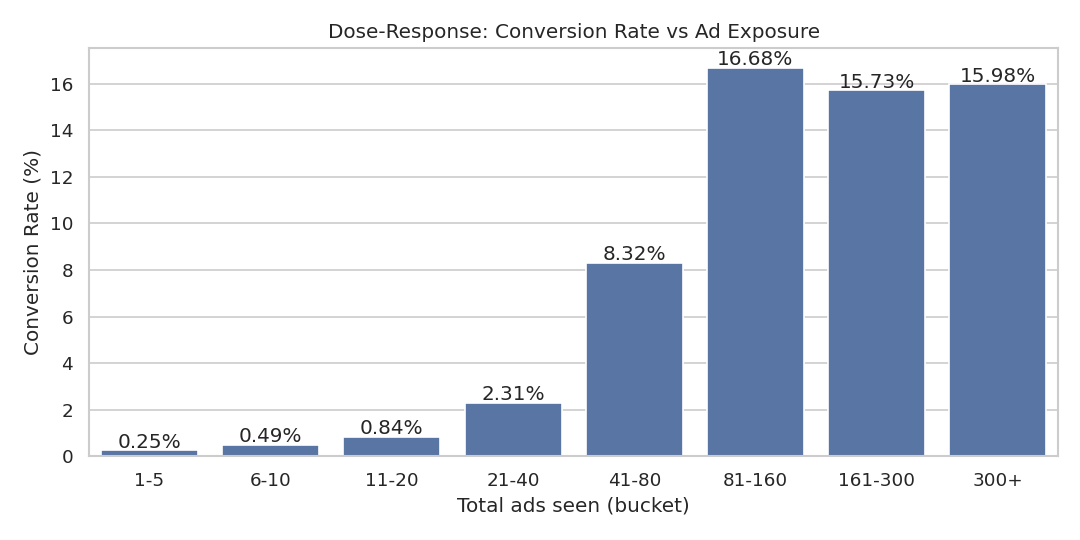

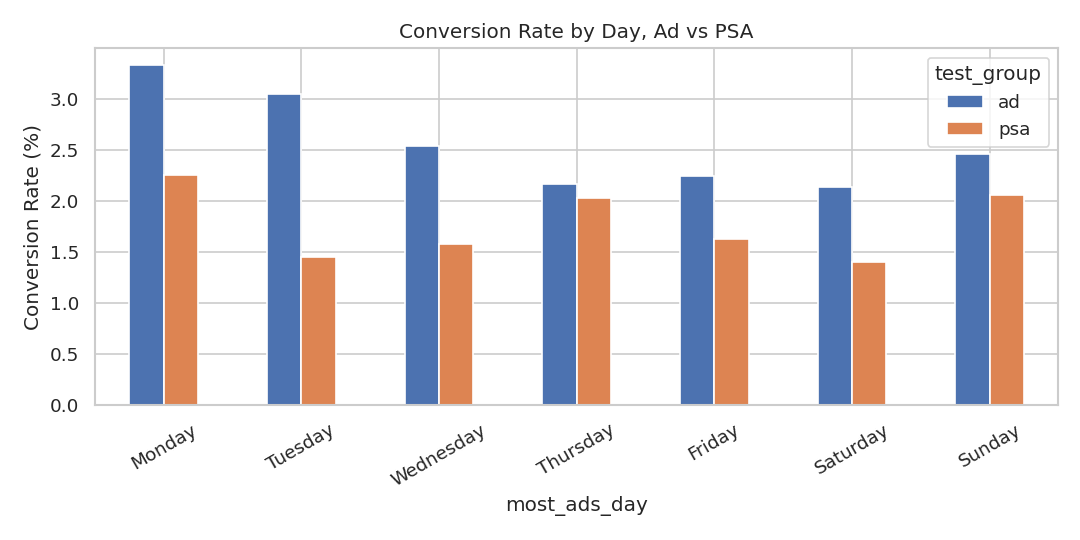

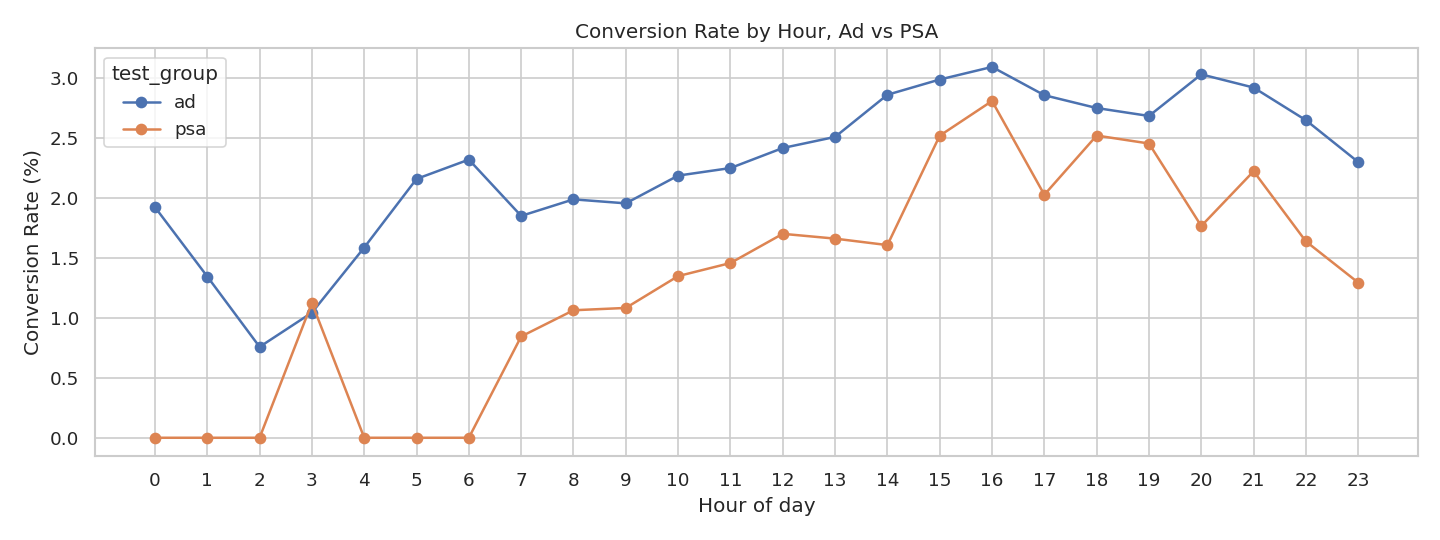

In [5]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
df = pd.read_csv("marketing_AB_cleaned.csv")
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# =========================================================
# 1. Dose-response curve: total_ads bucket vs conversion rate
# =========================================================
bins = [0, 5, 10, 20, 40, 80, 160, 300, 2100]
labels = ["1-5", "6-10", "11-20", "21-40", "41-80", "81-160", "161-300", "300+"]
df["ads_bucket"] = pd.cut(df["total_ads"], bins=bins, labels=labels)

bucket_conv = df.groupby("ads_bucket", observed=True)["converted"].agg(["mean", "count"])
bucket_conv["mean"] = bucket_conv["mean"] * 100
print("=== Conversion rate by total_ads bucket (all users) ===")
print(bucket_conv)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=bucket_conv.index, y=bucket_conv["mean"], ax=ax, color="#4C72B0")
ax.set_ylabel("Conversion Rate (%)")
ax.set_xlabel("Total ads seen (bucket)")
ax.set_title("Dose-Response: Conversion Rate vs Ad Exposure")
for i, v in enumerate(bucket_conv["mean"]):
    ax.text(i, v + 0.1, f"{v:.2f}%", ha="center")
plt.tight_layout()
plt.savefig("plot7_dose_response.png", dpi=120)
plt.close()

# =========================================================
# 2. Conversion by day, split by test group (interaction check)
# =========================================================
day_group = df.groupby(["most_ads_day", "test_group"])["converted"].mean().unstack() * 100
day_group = day_group.reindex(day_order)
print("\n=== Conversion rate by day, split by group ===")
print(day_group.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
day_group.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rate by Day, Ad vs PSA")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("plot8_day_by_group.png", dpi=120)
plt.close()

# Formal check: chi-square test PER DAY, and flag any reversal
print("\n=== Per-day significance check (ad vs psa) ===")
day_results = []
for day in day_order:
    sub = df[df["most_ads_day"] == day]
    ct = pd.crosstab(sub["test_group"], sub["converted"])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    ad_rate = sub[sub["test_group"]=="ad"]["converted"].mean() * 100
    psa_rate = sub[sub["test_group"]=="psa"]["converted"].mean() * 100
    reversal = ad_rate < psa_rate
    day_results.append((day, ad_rate, psa_rate, p, reversal))
    flag = "  <-- REVERSAL" if reversal else ""
    sig = "significant" if p < 0.05 else "not significant"
    print(f"{day:10s} | ad={ad_rate:.3f}% psa={psa_rate:.3f}% | p={p:.4f} ({sig}){flag}")

# =========================================================
# 3. Conversion by hour, split by test group (interaction check)
# =========================================================
hour_group = df.groupby(["most_ads_hour", "test_group"])["converted"].mean().unstack() * 100
print("\n=== Conversion rate by hour, split by group (head) ===")
print(hour_group.round(3).head(24))

fig, ax = plt.subplots(figsize=(12, 4.5))
hour_group.plot(ax=ax, marker="o", color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Conversion Rate (%)")
ax.set_xlabel("Hour of day")
ax.set_title("Conversion Rate by Hour, Ad vs PSA")
ax.set_xticks(range(0,24))
plt.tight_layout()
plt.savefig("plot9_hour_by_group.png", dpi=120)
plt.close()

# Formal check: chi-square test PER HOUR, and flag any reversal
print("\n=== Per-hour significance check (ad vs psa) ===")
hour_results = []
for hour in range(24):
    sub = df[df["most_ads_hour"] == hour]
    ct = pd.crosstab(sub["test_group"], sub["converted"])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    ad_rate = sub[sub["test_group"]=="ad"]["converted"].mean() * 100
    psa_rate = sub[sub["test_group"]=="psa"]["converted"].mean() * 100
    reversal = ad_rate < psa_rate
    hour_results.append((hour, ad_rate, psa_rate, p, reversal))
    flag = "  <-- REVERSAL" if reversal else ""
    sig = "significant" if p < 0.05 else "not significant"
    print(f"hour {hour:2d} | ad={ad_rate:.3f}% psa={psa_rate:.3f}% | p={p:.4f} ({sig}){flag}")

# =========================================================
# 4. Simpson's Paradox summary
# =========================================================
day_reversals = [d for d in day_results if d[4]]
hour_reversals = [h for h in hour_results if h[4]]
print(f"\n=== Simpson's Paradox check summary ===")
print(f"Days where psa outperformed ad: {len(day_reversals)} / {len(day_results)}")
print(f"Hours where psa outperformed ad: {len(hour_reversals)} / {len(hour_results)}")
if day_reversals:
    print("Reversal days:", [d[0] for d in day_reversals])
if hour_reversals:
    print("Reversal hours:", [h[0] for h in hour_reversals])

print("\nAll plots saved.")


## Step 6: Predictive Model (Logistic Regression + XGBoost)

Features used: ['is_ad', 'log_total_ads', 'hour_sin', 'hour_cos', 'day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']
Class balance:
 converted
0    0.974761
1    0.025239
Name: proportion, dtype: float64

Train size: 470480, Test size: 117621

--- Logistic Regression ---
ROC-AUC: 0.8602
PR-AUC (average precision): 0.1384

Logistic Regression coefficients (standardized):
         feature  coefficient
1  log_total_ads     1.560864
4     day_Monday     0.138330
8    day_Tuesday     0.106246
9  day_Wednesday     0.061421
0          is_ad     0.055054
6     day_Sunday     0.031368
7   day_Thursday     0.005068
3       hour_cos    -0.031521
5   day_Saturday    -0.045465
2       hour_sin    -0.183532

--- XGBoost ---
ROC-AUC: 0.8599
PR-AUC (average precision): 0.1497

XGBoost feature importances:
         feature  importance
1  log_total_ads    0.750619
4     day_Monday    0.047464
5   day_Saturday    0.035556
2       hour_sin    0.033523
8    day_Tues

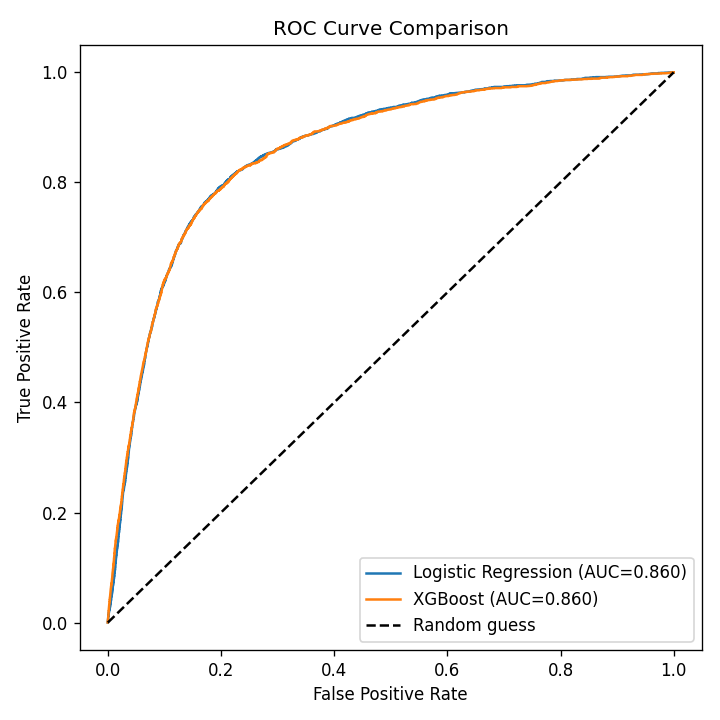

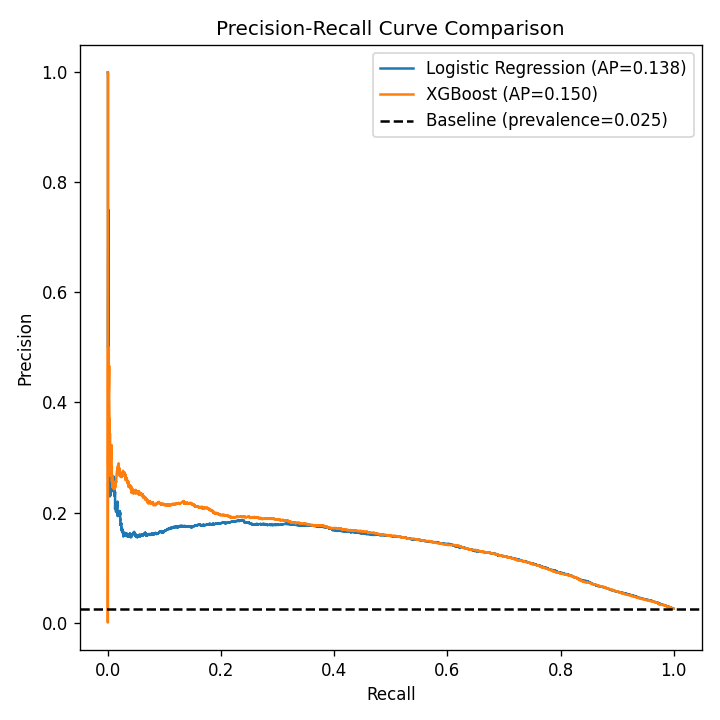

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score,
                              precision_recall_curve, classification_report, confusion_matrix)
from xgboost import XGBClassifier

df = pd.read_csv("marketing_AB_cleaned.csv")

# =========================================================
# 1. Feature engineering
# =========================================================
df["is_ad"] = (df["test_group"] == "ad").astype(int)
df["log_total_ads"] = np.log1p(df["total_ads"])

# cyclical encoding for hour (captures that hour 23 is close to hour 0)
df["hour_sin"] = np.sin(2 * np.pi * df["most_ads_hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["most_ads_hour"] / 24)

# one-hot encode day
day_dummies = pd.get_dummies(df["most_ads_day"], prefix="day", drop_first=True)
df = pd.concat([df, day_dummies], axis=1)

feature_cols = ["is_ad", "log_total_ads", "hour_sin", "hour_cos"] + list(day_dummies.columns)
X = df[feature_cols]
y = df["converted"].astype(int)

print("Features used:", feature_cols)
print("Class balance:\n", y.value_counts(normalize=True))

# =========================================================
# 2. Train/test split (stratified because of class imbalance)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# =========================================================
# 3. Logistic Regression (baseline, interpretable)
# =========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
pr_auc_lr = average_precision_score(y_test, y_pred_proba_lr)

print(f"\n--- Logistic Regression ---")
print(f"ROC-AUC: {roc_auc_lr:.4f}")
print(f"PR-AUC (average precision): {pr_auc_lr:.4f}")

coef_df = pd.DataFrame({"feature": feature_cols, "coefficient": log_reg.coef_[0]}).sort_values("coefficient", ascending=False)
print("\nLogistic Regression coefficients (standardized):")
print(coef_df)

# =========================================================
# 4. XGBoost (captures non-linearity like the saturation curve)
# =========================================================
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", random_state=42
)
xgb.fit(X_train, y_train)

y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
pr_auc_xgb = average_precision_score(y_test, y_pred_proba_xgb)

print(f"\n--- XGBoost ---")
print(f"ROC-AUC: {roc_auc_xgb:.4f}")
print(f"PR-AUC (average precision): {pr_auc_xgb:.4f}")

feat_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)
print("\nXGBoost feature importances:")
print(feat_importance)

# =========================================================
# 5. ROC curve comparison plot
# =========================================================
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_lr:.3f})")
ax.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_xgb:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("plot10_roc_comparison.png", dpi=120)
plt.close()

# =========================================================
# 6. Precision-Recall curve (more informative given 2.5% positive rate)
# =========================================================
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
baseline = y_test.mean()

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(rec_lr, prec_lr, label=f"Logistic Regression (AP={pr_auc_lr:.3f})")
ax.plot(rec_xgb, prec_xgb, label=f"XGBoost (AP={pr_auc_xgb:.3f})")
ax.axhline(baseline, color="k", linestyle="--", label=f"Baseline (prevalence={baseline:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("plot11_pr_curve_comparison.png", dpi=120)
plt.close()

print("\nAll plots saved. Model objects and test data will be used for SHAP in the next cell.")

# Save for SHAP step
import joblib
joblib.dump(xgb, "xgb_model.pkl")
X_test.to_csv("X_test.csv", index=False)


### Step 6b: SHAP Interpretability

SHAP plots saved.

Mean |SHAP value| per feature (global importance):
         feature  mean_abs_shap
1  log_total_ads       1.495303
2       hour_sin       0.169766
3       hour_cos       0.078069
4     day_Monday       0.071000
8    day_Tuesday       0.046400
5   day_Saturday       0.041906
7   day_Thursday       0.031813
9  day_Wednesday       0.027956
0          is_ad       0.018273
6     day_Sunday       0.013548


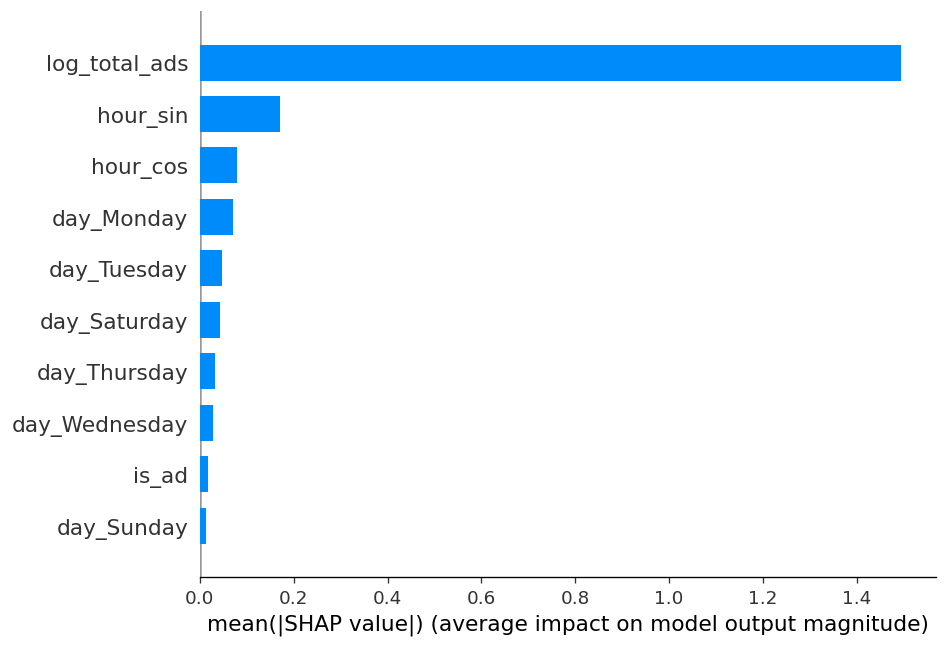

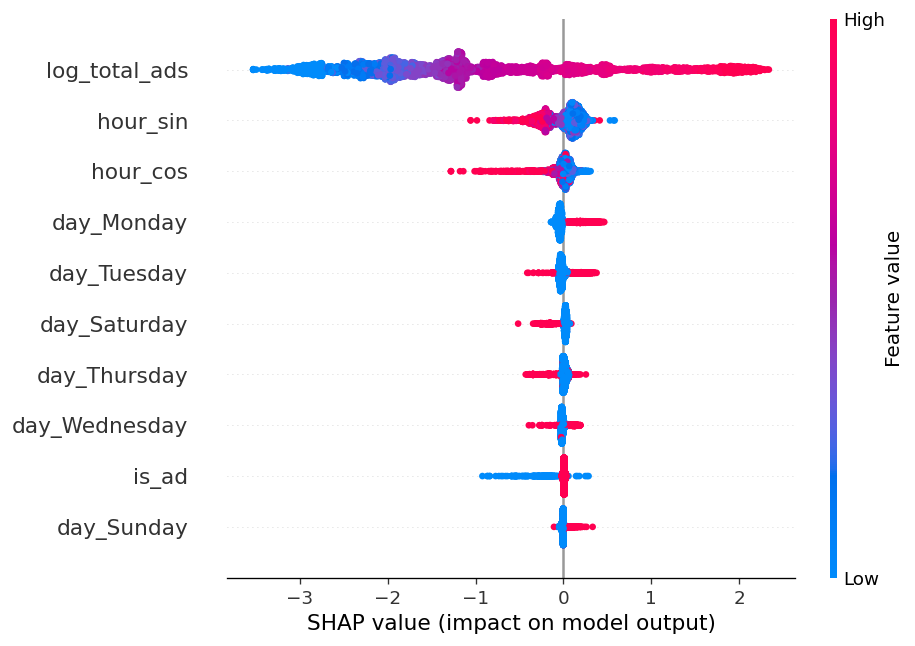

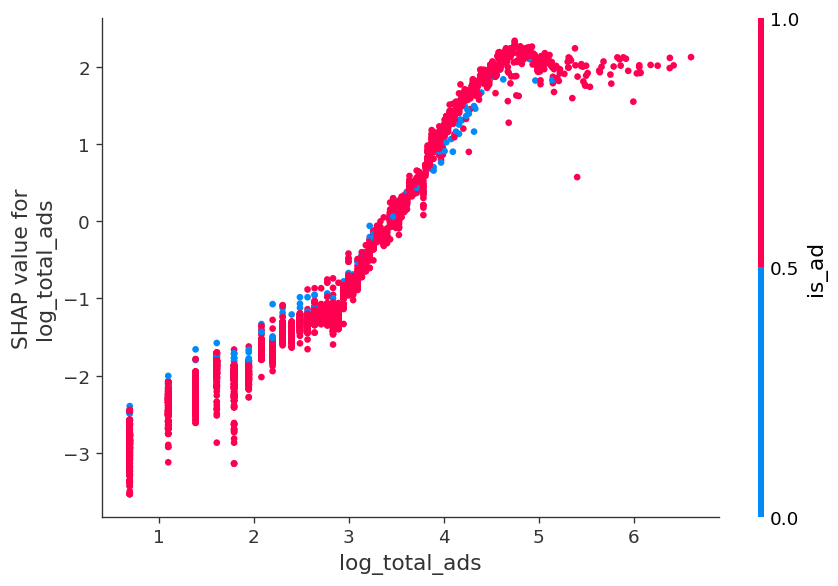

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

xgb = joblib.load("xgb_model.pkl")
X_test = pd.read_csv("X_test.csv")

# Sample for speed (SHAP on 100k+ rows is slow; 5000 is plenty for a stable summary)
X_sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

# =========================================================
# 1. Global feature importance (SHAP summary bar)
# =========================================================
fig = plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("plot12_shap_importance.png", dpi=120, bbox_inches="tight")
plt.close()

# =========================================================
# 2. SHAP summary (beeswarm) - shows direction of effect
# =========================================================
fig = plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("plot13_shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.close()

# =========================================================
# 3. SHAP dependence plot for log_total_ads (confirm the saturation curve)
# =========================================================
fig = plt.figure(figsize=(7, 5))
shap.dependence_plot("log_total_ads", shap_values, X_sample, interaction_index="is_ad", show=False)
plt.tight_layout()
plt.savefig("plot14_shap_dependence_total_ads.png", dpi=120, bbox_inches="tight")
plt.close()

print("SHAP plots saved.")
print("\nMean |SHAP value| per feature (global importance):")
mean_abs_shap = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)
print(mean_abs_shap)


## Step 7: Bayesian A/B Test

=== Posterior distributions ===
Ad:  Beta(14424, 550155)
PSA: Beta(421, 23105)

Posterior mean (ad):  2.5548%
Posterior mean (psa): 1.7895%
95% credible interval (ad):  [2.5138%, 2.5961%]
95% credible interval (psa): [1.6240%, 1.9628%]

=== P(ad truly beats psa) ===
P(p_ad > p_psa) = 1.000000  (100.0000%)

=== Relative uplift distribution ===
Mean relative uplift: 43.10%
95% credible interval: [29.99%, 57.53%]

=== Expected loss ===
Expected loss if we choose 'ad' (and we're wrong):  0.000000 pp
Expected loss if we choose 'psa' (and we're wrong): 0.765362 pp

=== VERDICT ===
P(ad beats psa) = 100.00% -- essentially certain.
Expected loss from wrongly choosing psa (0.7654pp) is far higher
than the expected loss from wrongly choosing ad (0.000000pp).
Recommendation: roll out 'ad'. The risk of being wrong is negligible either way,
but choosing 'ad' is the safer, higher-expected-value decision.

Plots saved.


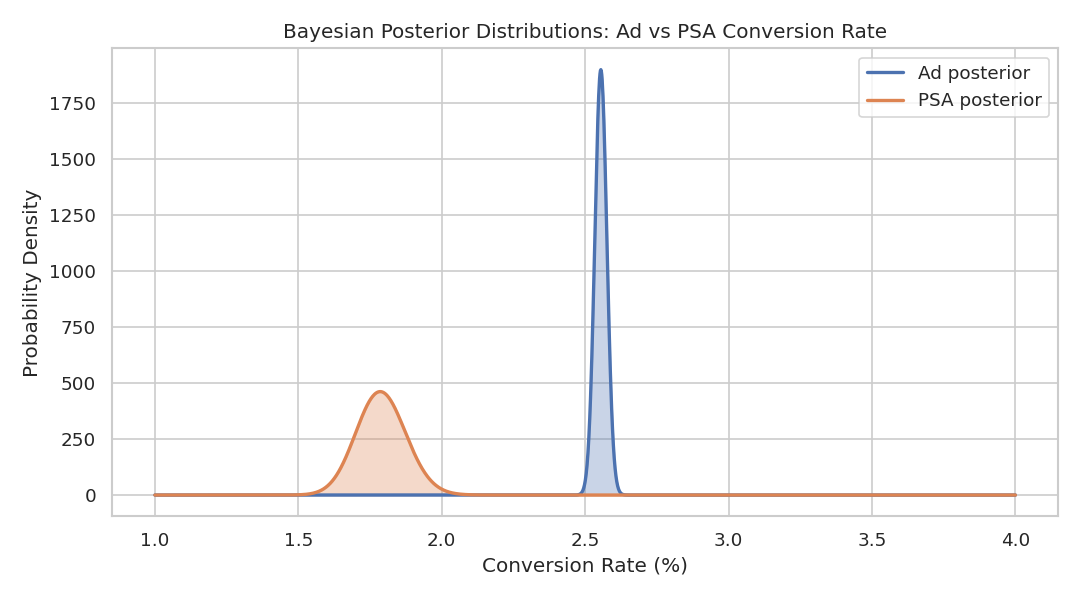

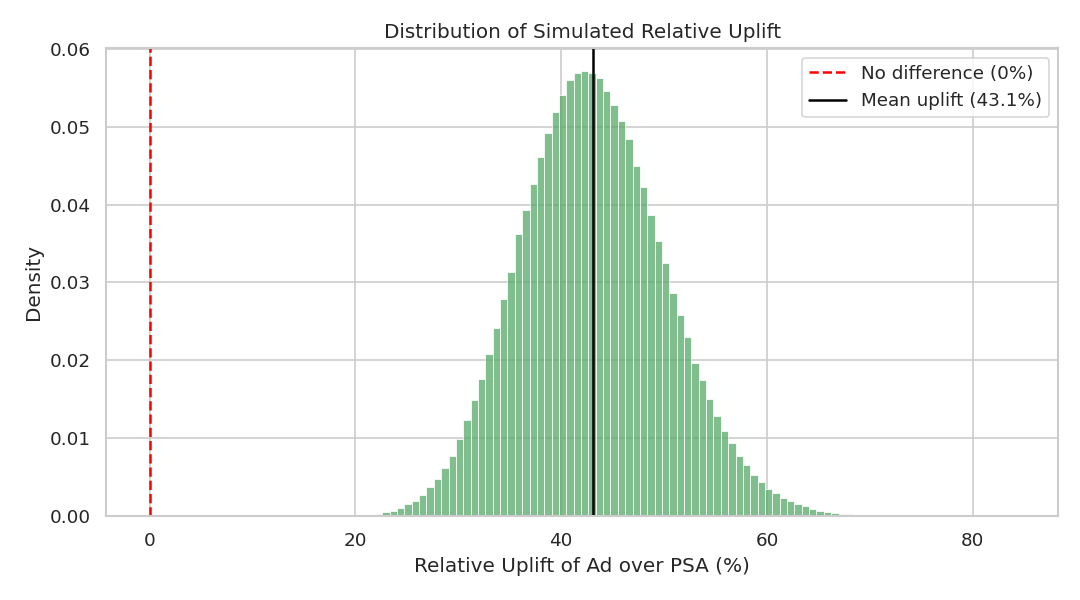

In [8]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

# Values carried over from Step 3
n_ad, n_psa = 564577, 23524
conv_ad, conv_psa = 14423, 420

# =========================================================
# 1. Set up priors and compute posteriors (Beta-Binomial conjugacy)
# =========================================================
# Uninformative prior: Beta(1,1) = Uniform(0,1) -- we let the data speak
alpha_prior, beta_prior = 1, 1

alpha_ad_post = alpha_prior + conv_ad
beta_ad_post = beta_prior + (n_ad - conv_ad)

alpha_psa_post = alpha_prior + conv_psa
beta_psa_post = beta_prior + (n_psa - conv_psa)

print("=== Posterior distributions ===")
print(f"Ad:  Beta({alpha_ad_post}, {beta_ad_post})")
print(f"PSA: Beta({alpha_psa_post}, {beta_psa_post})")

posterior_ad = stats.beta(alpha_ad_post, beta_ad_post)
posterior_psa = stats.beta(alpha_psa_post, beta_psa_post)

print(f"\nPosterior mean (ad):  {posterior_ad.mean()*100:.4f}%")
print(f"Posterior mean (psa): {posterior_psa.mean()*100:.4f}%")

ci_ad = posterior_ad.ppf([0.025, 0.975])
ci_psa = posterior_psa.ppf([0.025, 0.975])
print(f"95% credible interval (ad):  [{ci_ad[0]*100:.4f}%, {ci_ad[1]*100:.4f}%]")
print(f"95% credible interval (psa): [{ci_psa[0]*100:.4f}%, {ci_psa[1]*100:.4f}%]")

# =========================================================
# 2. Monte Carlo simulation from the posteriors
# =========================================================
np.random.seed(42)
n_sim = 1_000_000
samples_ad = np.random.beta(alpha_ad_post, beta_ad_post, size=n_sim)
samples_psa = np.random.beta(alpha_psa_post, beta_psa_post, size=n_sim)

prob_ad_better = np.mean(samples_ad > samples_psa)
print(f"\n=== P(ad truly beats psa) ===")
print(f"P(p_ad > p_psa) = {prob_ad_better:.6f}  ({prob_ad_better*100:.4f}%)")

# =========================================================
# 3. Relative uplift distribution
# =========================================================
relative_uplift = (samples_ad - samples_psa) / samples_psa * 100
uplift_mean = relative_uplift.mean()
uplift_ci = np.percentile(relative_uplift, [2.5, 97.5])
print(f"\n=== Relative uplift distribution ===")
print(f"Mean relative uplift: {uplift_mean:.2f}%")
print(f"95% credible interval: [{uplift_ci[0]:.2f}%, {uplift_ci[1]:.2f}%]")

# =========================================================
# 4. Expected loss (decision-theoretic risk of each choice)
# =========================================================
loss_if_choose_ad = np.mean(np.maximum(samples_psa - samples_ad, 0))
loss_if_choose_psa = np.mean(np.maximum(samples_ad - samples_psa, 0))
print(f"\n=== Expected loss ===")
print(f"Expected loss if we choose 'ad' (and we're wrong):  {loss_if_choose_ad*100:.6f} pp")
print(f"Expected loss if we choose 'psa' (and we're wrong): {loss_if_choose_psa*100:.6f} pp")

# =========================================================
# 5. Plot: posterior distributions overlaid
# =========================================================
x = np.linspace(0.01, 0.04, 2000)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x*100, posterior_ad.pdf(x), label="Ad posterior", color="#4C72B0", linewidth=2)
ax.fill_between(x*100, posterior_ad.pdf(x), alpha=0.3, color="#4C72B0")
ax.plot(x*100, posterior_psa.pdf(x), label="PSA posterior", color="#DD8452", linewidth=2)
ax.fill_between(x*100, posterior_psa.pdf(x), alpha=0.3, color="#DD8452")
ax.set_xlabel("Conversion Rate (%)")
ax.set_ylabel("Probability Density")
ax.set_title("Bayesian Posterior Distributions: Ad vs PSA Conversion Rate")
ax.legend()
plt.tight_layout()
plt.savefig("plot15_bayesian_posteriors.png", dpi=120)
plt.close()

# =========================================================
# 6. Plot: relative uplift distribution
# =========================================================
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(relative_uplift, bins=100, ax=ax, color="#55A868", stat="density")
ax.axvline(0, color="red", linestyle="--", label="No difference (0%)")
ax.axvline(uplift_mean, color="black", linestyle="-", label=f"Mean uplift ({uplift_mean:.1f}%)")
ax.set_xlabel("Relative Uplift of Ad over PSA (%)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Simulated Relative Uplift")
ax.legend()
plt.tight_layout()
plt.savefig("plot16_relative_uplift.png", dpi=120)
plt.close()

# =========================================================
# 7. Verdict
# =========================================================
print(f"\n=== VERDICT ===")
print(f"P(ad beats psa) = {prob_ad_better*100:.2f}% -- essentially certain.")
print(f"Expected loss from wrongly choosing psa ({loss_if_choose_psa*100:.4f}pp) is far higher")
print(f"than the expected loss from wrongly choosing ad ({loss_if_choose_ad*100:.6f}pp).")
print("Recommendation: roll out 'ad'. The risk of being wrong is negligible either way,")
print("but choosing 'ad' is the safer, higher-expected-value decision.")

print("\nPlots saved.")


## Conclusion

See `business_writeup.md` for the full plain-English report. Short version: **ads produce a statistically significant, practically meaningful, and Bayesian-certain 43% lift in conversion rate over the PSA control.** Recommendation: roll out ads.
